# Welcome to *Amantle's Project!*





**Brain Tumour MRI Classification Using Deep Learning**

*Project Overview*

This project investigates the use of deep learning for multiclass brain tumour classification using MRI images. The study compares a custom Convolutional Neural Network (CNN) with transfer learning architectures including VGG16, ResNet50, and EfficientNetB0. The objective is to determine which model provides the best balance between classification accuracy, generalisation, and computational efficiency.

*Dataset*

The project uses the Brain Tumor MRI Dataset by Masoud Nickparvar from Kaggle. The dataset contains MRI images grouped into four classes:

- Glioma
- Meningioma
- Pituitary Tumour
- No Tumour

The dataset is divided into training, validation, and testing sets for supervised learning.

*Technologies and Frameworks*

The models were implemented using:

Python, TensorFlow, Keras, NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn

Google Colab with T4 GPU acceleration was used for model training.

## SECTION 1: INSTALL & DATASET DOWNLOAD

In [ ]:
!pip install kagglehub -q

import kagglehub
import os

*Downloads and caches the dataset — no API key or Drive mount was used*

In [ ]:
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset path:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset path: /kaggle/input/brain-tumor-mri-dataset


## Set Training and Testing directory paths





In [ ]:
train_dir = os.path.join(path, "Training")
test_dir  = os.path.join(path, "Testing")
print("Training folder:", train_dir)
print("Testing folder :", test_dir)
print("Classes found  :", os.listdir(train_dir))

Training folder: /kaggle/input/brain-tumor-mri-dataset/Training
Testing folder : /kaggle/input/brain-tumor-mri-dataset/Testing
Classes found  : ['pituitary', 'notumor', 'meningioma', 'glioma']


# SECTION 2: IMPORTS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize


*Confirm GPU is active — should show PhysicalDevice with name '/GPU:0'*

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU devices      :", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


*Mixed precision: cuts memory usage and speeds up GPU training significantly*

In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Precision policy :", mixed_precision.global_policy().name)

Precision policy : mixed_float16


# SECTION 3: CONFIGURATION

IMG_SIZE is set to 128x128 to speed up Custom CNN training.


*   Transfer learning models (VGG16, ResNet50, EfficientNetB0) will also
use 128x128 .




In [ ]:
IMG_SIZE     = (128, 128)   # Smaller size = faster training for custom CNN
BATCH_SIZE   = 32
SEED         = 42
NUM_CLASSES  = 4
EPOCHS       = 10           # Early stopping will halt training if val_loss plateaus
LR           = 0.001
DROPOUT      = 0.4


# SECTION 4: DATA GENERATORS (Preprocessing and Data Augmentation)

Validation and test sets are rescaled only , no augmentation.

Data augmentation was applied only to the training set to improve generalisation and reduce overfitting.
      
MRI images were resized to 128×128 pixels for computational efficiency and fair model comparison. Image preprocessing included:


1.   Rescaling pixel values
2.   Rotation augmentation
3. Zoom augmentation
4. Width and height shifting
5. Horizontal flipping
6. Shearing


Data augmentation was applied only to the training set to improve generalisation and reduce overfitting.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,   # 20% of training data reserved for validation
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    fill_mode="nearest"
)
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

## Load training set

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

Found 4480 images belonging to 4 classes.


## Load validation set

In [ ]:
val_data = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

Found 1120 images belonging to 4 classes.



## Load test set
Shuffle=False in the below code keeps label order consistent for evaluation

In [ ]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

CLASS_NAMES = list(train_data.class_indices.keys())

print("\nClass indices     :", train_data.class_indices)
print("Class names       :", CLASS_NAMES)
print("Training images   :", train_data.samples)
print("Validation images :", val_data.samples)
print("Test images       :", test_data.samples)

Found 1600 images belonging to 4 classes.

Class indices     : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Class names       : ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images   : 4480
Validation images : 1120
Test images       : 1600


# SECTION 5: EXPLORATORY DATA ANALYSIS

## Class distribution — training set

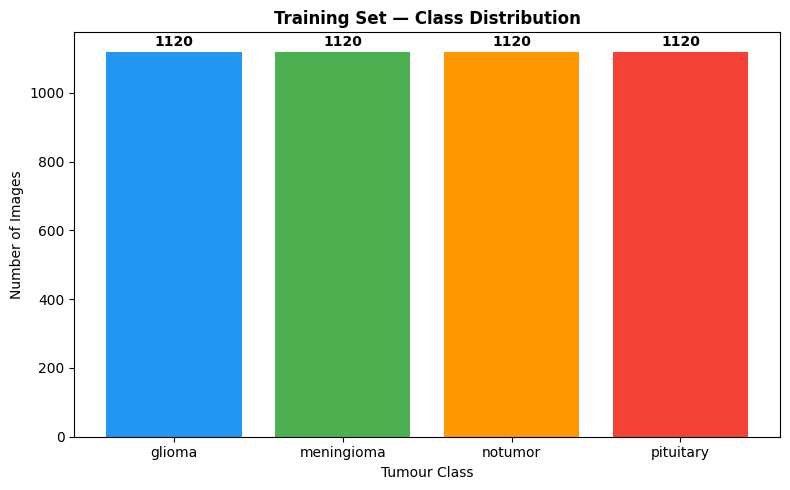

In [ ]:
counts = np.bincount(train_data.classes)
plt.figure(figsize=(8, 5))
bars = plt.bar(CLASS_NAMES, counts,
               color=["#2196F3","#4CAF50","#FF9800","#F44336"])
plt.title("Training Set — Class Distribution", fontweight="bold")
plt.xlabel("Tumour Class")
plt.ylabel("Number of Images")
for bar, c in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 15, str(c), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## Sample MRI images — one batch from the training generator



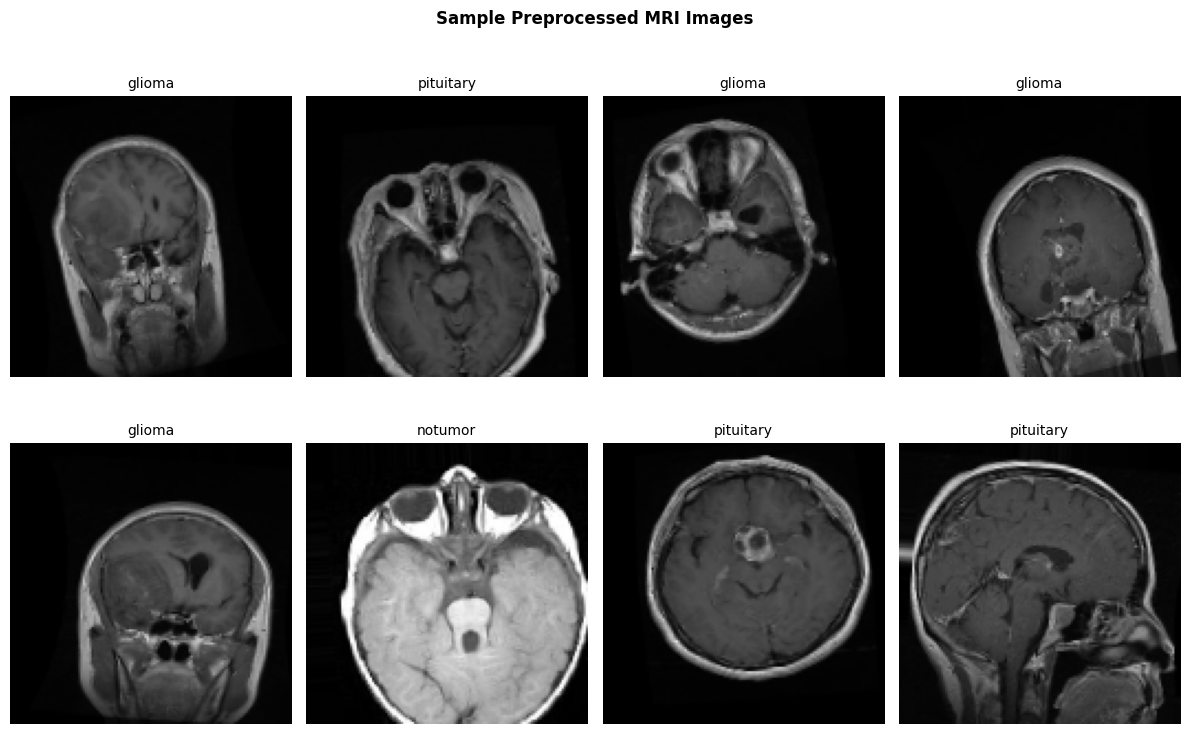

In [ ]:
images, labels = next(train_data)
plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(CLASS_NAMES[np.argmax(labels[i])], fontsize=10)
    plt.axis("off")
plt.suptitle("Sample Preprocessed MRI Images", fontweight="bold")
plt.tight_layout()
plt.show()

# SECTION 6: CLASS WEIGHTS

The dataset has a slight class imbalance (no-tumour class is larger).
Class weights penalise the model more for errors on minority classes, helping it learn balanced representations across all four categories.


In [ ]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


# SECTION 7: CALLBACKS

 - EarlyStopping  stops training when val_loss stops improving (patience=5)
- ReduceLROnPlateau
halves learning rate when val_loss plateaus (patience=3)
ModelCheckpoint — saves the best model weights during training

In [ ]:

def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=f"{model_name}_best.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

# **# CUSTOM CNN**

A custom CNN architecture was developed as the baseline model. The architecture consists of:

- Convolutional layers
- Batch Normalisation
- MaxPooling layers
- Global Average Pooling
- Dense fully connected layers
- Dropout regularisation

The model was trained using the Adam optimiser and categorical cross-entropy loss function.

# SECTION 8: BUILD CUSTOM CNN

Architecture: 4 convolutional blocks (32→64→128→256 filters)→ GlobalAveragePooling → Dense(128) → Dropout → Softmax
Design choices:
 - BatchNormalization after each Conv layer stabilises training
- GlobalAveragePooling replaces Flatten to reduce parameters
 - Dropout(0.4) reduces overfitting in the fully connected layer - dtype='float32' on output required for mixed precision stability

In [ ]:
def build_custom_cnn(input_shape=(128, 128, 3), num_classes=4):
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 4
        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Classification head
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(DROPOUT),

        # float32 cast — required for mixed precision numerical stability
        layers.Dense(num_classes, activation="softmax", dtype="float32")

    ], name="Custom_CNN_Baseline")

    return model


custom_cnn = build_custom_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
custom_cnn.summary()

Model: "Custom_CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

# SECTION 9: COMPILE & TRAIN

In [ ]:
custom_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

import time
start = time.time()

history_cnn = custom_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=get_callbacks("custom_cnn"),
    class_weight=class_weights,
    verbose=1
)

elapsed = round((time.time() - start) / 60, 2)
print(f"\nTraining completed in {elapsed} minutes")

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.6395 - loss: 0.9078
Epoch 1: val_loss improved from None to 7.16851, saving model to custom_cnn_best.keras

Epoch 1: finished saving model to custom_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 237ms/step - accuracy: 0.6967 - loss: 0.7678 - val_accuracy: 0.2500 - val_loss: 7.1685 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7947 - loss: 0.5421
Epoch 2: val_loss did not improve from 7.16851
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - accuracy: 0.8076 - loss: 0.5191 - val_accuracy: 0.2500 - val_loss: 9.9381 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8318 - loss: 0.4623
Epoch 3: val_loss improved from 7.16851 to 3.34319, saving model to custom_cnn_best.keras

Epoch 3: finished saving model to custom_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - accuracy: 0.8362 - loss: 0.4435 - val_accuracy: 0.4330 - val_los

# SECTION 10: TRAINING CURVES

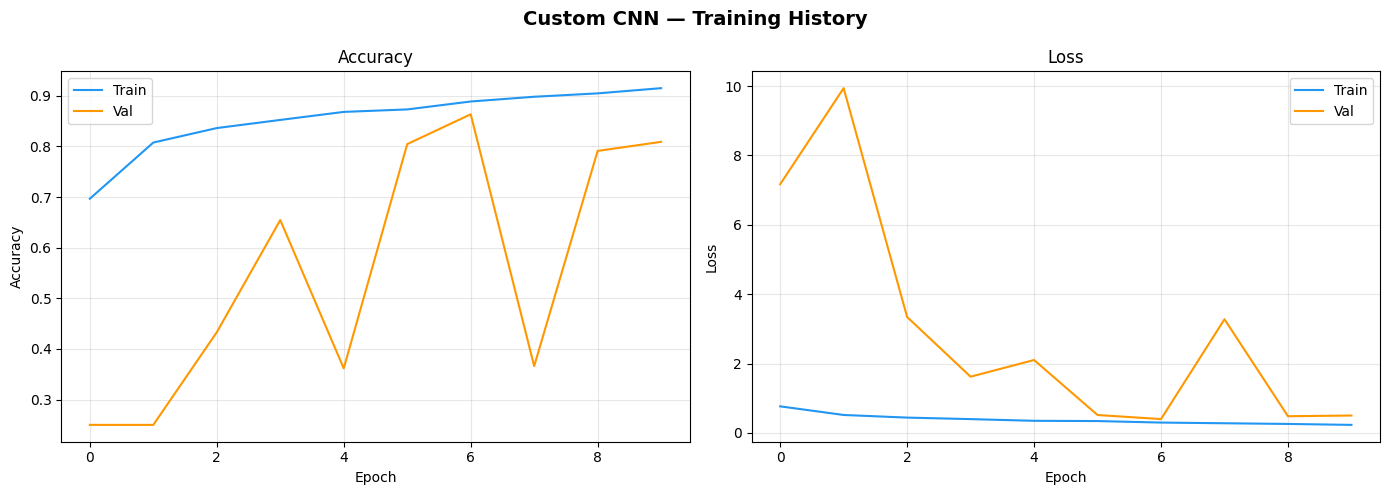

In [ ]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training History", fontsize=14, fontweight="bold")

    axes[0].plot(history.history["accuracy"],     label="Train", color="#2196F3")
    axes[0].plot(history.history["val_accuracy"], label="Val",   color="#FF9800")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["loss"],     label="Train", color="#2196F3")
    axes[1].plot(history.history["val_loss"], label="Val",   color="#FF9800")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Custom CNN")

# SECTION 11: EVALUATION


 This section generates:
 - Classification report (precision, recall, F1 per class)
  - Confusion matrix heatmap
  - ROC-AUC curves (one-vs-rest per class)
 - Overall test accuracy, loss, macro AUC

### Classification Report

In [ ]:
test_data.reset()
y_pred_proba = custom_cnn.predict(test_data, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_data.classes

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.56      0.70       400
  meningioma       0.66      0.72      0.69       400
     notumor       0.86      0.93      0.89       400
   pituitary       0.74      0.92      0.82       400

    accuracy                           0.78      1600
   macro avg       0.80      0.78      0.78      1600
weighted avg       0.80      0.78      0.78      1600



### Confusion matrix

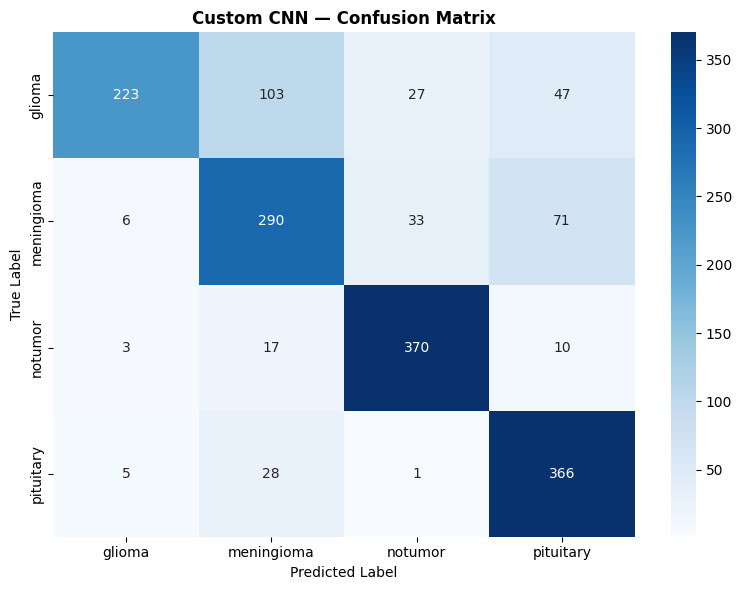

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Custom CNN — Confusion Matrix", fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

### ROC-AUC curves

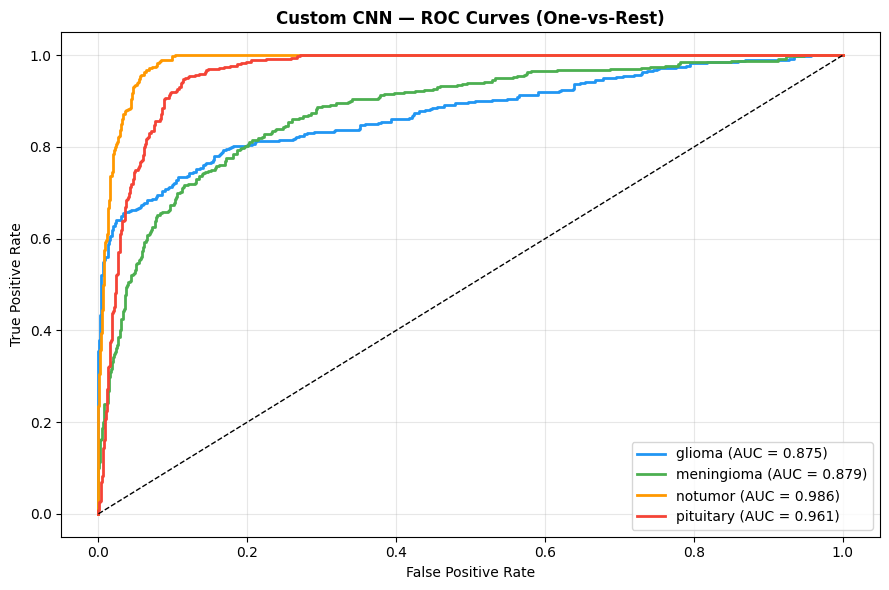

In [ ]:
# ROC-AUC curves
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
colours = ["#2196F3","#4CAF50","#FF9800","#F44336"]
plt.figure(figsize=(9, 6))
auc_scores = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colours)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    score = auc(fpr, tpr)
    auc_scores.append(score)
    plt.plot(fpr, tpr, color=col, lw=2, label=f"{cls} (AUC = {score:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Custom CNN — ROC Curves (One-vs-Rest)", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test accuracy and loss

In [ ]:
test_data.reset()
test_loss, test_acc = custom_cnn.evaluate(test_data, verbose=0)
macro_auc = np.mean(auc_scores)

print(f"\n{'='*45}")
print(f"  Custom CNN — Final Results")
print(f"{'='*45}")
print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Macro AUC     : {macro_auc:.4f}")
print(f"  Training Time : {elapsed} minutes")
print(f"{'='*45}")


  Custom CNN — Final Results
  Test Accuracy : 0.7806
  Test Loss     : 0.8005
  Macro AUC     : 0.9254
  Training Time : 5.71 minutes


# SECTION 12: SAVE MODEL CNN

In [ ]:
# Save the final model — load later with tf.keras.models.load_model()
custom_cnn.save("custom_cnn_final.keras")
print("Model saved as custom_cnn_final.keras")

Model saved as custom_cnn_final.keras


# TRANSFER LEARNING MODELS

Three transfer learning architectures were implemented:
1. VGG16

VGG16 was used as a pretrained feature extractor with fine-tuning applied to the final layers.

2. ResNet50

ResNet50 uses residual connections to improve gradient flow and support deeper learning architectures.

3. EfficientNetB0

EfficientNetB0 applies compound scaling to balance network depth, width, and image resolution while maintaining computational efficiency.

# **# VGG16 Transfer Learning**

Two-Phase Training Strategy:
 -  Phase 1 — Feature Extraction : VGG16 base frozen, only head trained (LR=0.001)
- Phase 2 — Fine-Tuning        : Last 4 base layers unfrozen (LR=0.0001)

VGG16 — LOAD PRETRAINED BASE

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

*Reloading generators at 128x128, same size as Custom CNN for fair comparison*

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE_TL  = (128, 128)   # Same as Custom CNN — consistent for fair comparison
BATCH_SIZE   = 32
SEED         = 42

In [ ]:
 train_datagen_tl = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    fill_mode="nearest"
)

val_datagen_tl = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

test_datagen_tl = ImageDataGenerator(rescale=1.0 / 255)

train_data_tl = train_datagen_tl.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_data_tl = val_datagen_tl.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

test_data_tl = test_datagen_tl.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("128x128 generators ready for transfer learning.")
print("Train:", train_data_tl.samples,
      "| Val:", val_data_tl.samples,
      "| Test:", test_data_tl.samples)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
128x128 generators ready for transfer learning.
Train: 4480 | Val: 1120 | Test: 1600


# SECTION 14: BUILD VGG16 MODEL

In [ ]:
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freezing entire base for Phase 1 (feature extraction only)
vgg_base.trainable = False

print(f"VGG16 base layers: {len(vgg_base.layers)}")
print(f"Trainable layers (Phase 1): {sum(1 for l in vgg_base.layers if l.trainable)}")

VGG16 base layers: 19
Trainable layers (Phase 1): 0


In [ ]:
# Building full model by attaching classification head to frozen base
def build_transfer_model(base_model, num_classes, model_name):
    """
    Shared classification head for all transfer learning models:
    GlobalAveragePooling → Dense(256, ReLU) → Dropout(0.5) → Softmax(4)
    dtype='float32' on output layer for mixed precision stability.
    """
    inputs  = base_model.input
    x       = base_model.output
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation="relu")(x)
    x       = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax",
                           dtype="float32")(x)
    return models.Model(inputs, outputs, name=model_name)


vgg_model = build_transfer_model(vgg_base, NUM_CLASSES, "VGG16")
vgg_model.summary()

Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# SECTION 15: PHASE 1 — FEATURE EXTRACTION (FROZEN BASE)

 - Only the classification head is trained here.
- Base weights are frozen to preserve pretrained ImageNet features.
- LR = 0.001 — standard rate for training a fresh classification head.

In [ ]:
EPOCHS_P1 = 10
LR_P1     = 0.001

vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P1),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n" + "="*60)
print("  VGG16 — Phase 1: Feature Extraction (Base Frozen)")
print("="*60)
start = time.time()

history_vgg_p1 = vgg_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=EPOCHS_P1,
    callbacks=get_callbacks("vgg16_phase1"),
    class_weight=class_weights,
    verbose=1
)

p1_time = round((time.time() - start) / 60, 2)
print(f"Phase 1 completed in {p1_time} minutes")


  VGG16 — Phase 1: Feature Extraction (Base Frozen)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.5091 - loss: 1.1461
Epoch 1: val_loss improved from None to 0.61001, saving model to vgg16_phase1_best.keras

Epoch 1: finished saving model to vgg16_phase1_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 278ms/step - accuracy: 0.6292 - loss: 0.9151 - val_accuracy: 0.7973 - val_loss: 0.6100 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.7845 - loss: 0.6147
Epoch 2: val_loss improved from 0.61001 to 0.49574, saving model to vgg16_phase1_best.keras

Epoch 2: finished saving model to vgg16_phase1_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 295ms/step - accuracy: 0.7799 - loss: 0.6039 - val_accuracy: 0.8357 - val_loss: 0.4957 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.8002 - loss: 0.5515
Epoch 3: val_loss improved from 0.49574 to 0.46044, saving model to vgg16_phase1_best.keras

Epo

## Phase 1 training curves

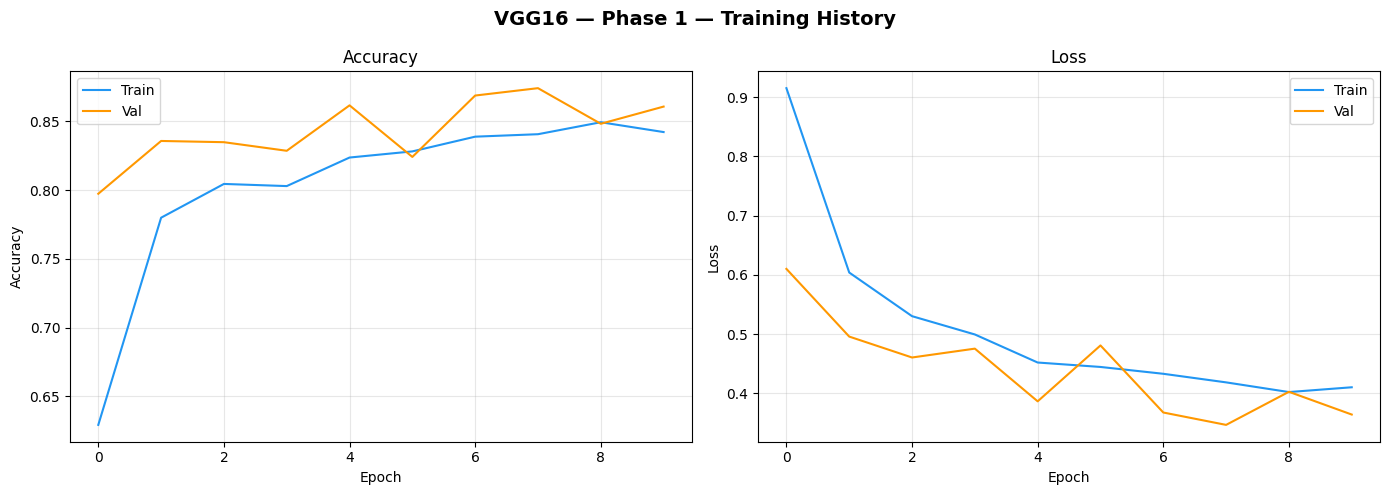

In [ ]:
plot_history(history_vgg_p1, "VGG16 — Phase 1")

# SECTION 16: PHASE 2 — FINE-TUNING (UNFREEZE LAST 4 LAYERS)

 Unfreezing the last 4 layers of VGG16 base (final conv block).
- Lower LR = 0.0001 prevents overwriting pretrained weights too aggressively.
- Rest of base stays frozen to retain low-level feature representations.

In [ ]:
vgg_base.trainable = True
# Freeze all layers except the last 4
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
    trainable = sum(1 for l in vgg_model.layers if l.trainable)
print(f"\nTrainable layers after unfreeze: {trainable}")

EPOCHS_P2 = 10
LR_P2     = 0.0001


Trainable layers after unfreeze: 8


In [ ]:
# Recompiling at lower learning rate for fine-tuning
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("\n" + "="*60)
print("  VGG16 — Phase 2: Fine-Tuning (Last 4 Layers Unfrozen)")
print("="*60)

start = time.time()

history_vgg_p2 = vgg_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=EPOCHS_P2,
    callbacks=get_callbacks("vgg16_phase2"),
    class_weight=class_weights,
    verbose=1
)

p2_time = round((time.time() - start) / 60, 2)
print(f"Phase 2 completed in {p2_time} minutes")


  VGG16 — Phase 2: Fine-Tuning (Last 4 Layers Unfrozen)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.7364 - loss: 0.8395
Epoch 1: val_loss improved from None to 0.28594, saving model to vgg16_phase2_best.keras

Epoch 1: finished saving model to vgg16_phase2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 276ms/step - accuracy: 0.8152 - loss: 0.5293 - val_accuracy: 0.8875 - val_loss: 0.2859 - learning_rate: 1.0000e-04
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.8773 - loss: 0.3130
Epoch 2: val_loss improved from 0.28594 to 0.23052, saving model to vgg16_phase2_best.keras

Epoch 2: finished saving model to vgg16_phase2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 285ms/step - accuracy: 0.8848 - loss: 0.3021 - val_accuracy: 0.9161 - val_loss: 0.2305 - learning_rate: 1.0000e-04
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9083 - loss: 0.2529
Epoch 3: val_loss improved from 0.23052 to 0.22249, saving model to vgg16_phase2_bes

## Phase 2 training curves

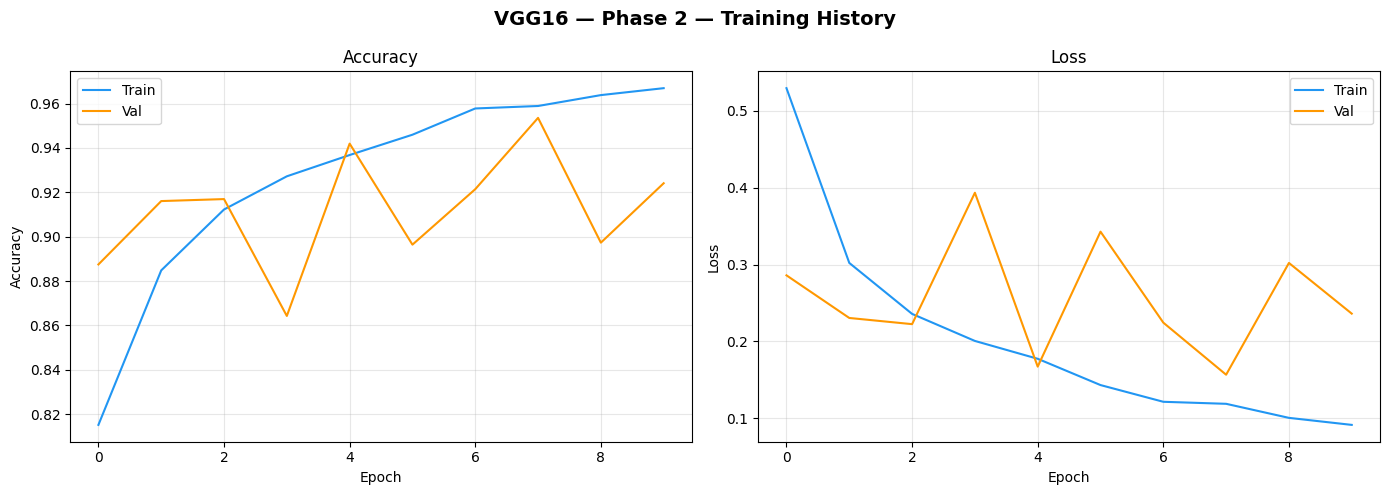

In [ ]:
plot_history(history_vgg_p2, "VGG16 — Phase 2")

# SECTION 17: VGG16 EVALUATION

In [ ]:
test_data_tl.reset()
y_pred_proba_vgg = vgg_model.predict(test_data_tl, verbose=1)
y_pred_vgg       = np.argmax(y_pred_proba_vgg, axis=1)
y_true_vgg       = test_data_tl.classes

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step


## Classification report

In [ ]:
# Classification report
print("\nVGG16 — Classification Report:")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=CLASS_NAMES))


VGG16 — Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.76      0.85       400
  meningioma       0.84      0.90      0.87       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.92      0.99      0.95       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



## Confusion matrix

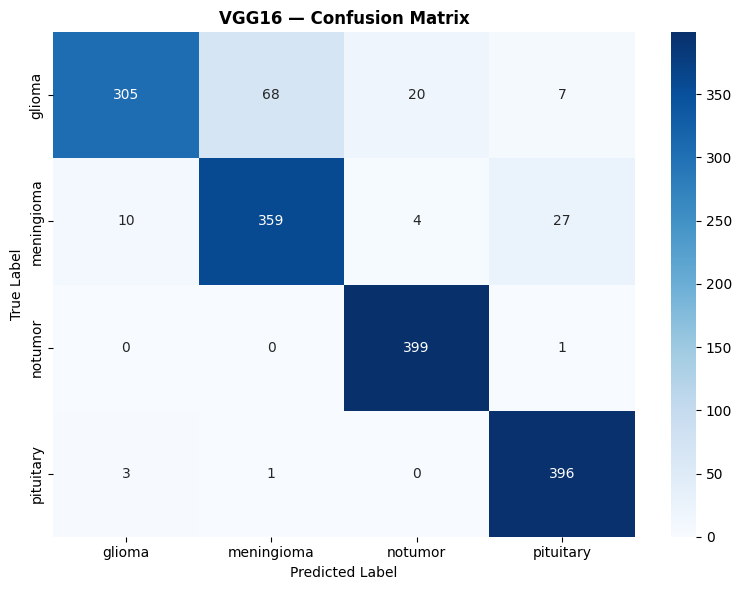

In [ ]:
# Confusion matrix
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("VGG16 — Confusion Matrix", fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## ROC-AUC curves

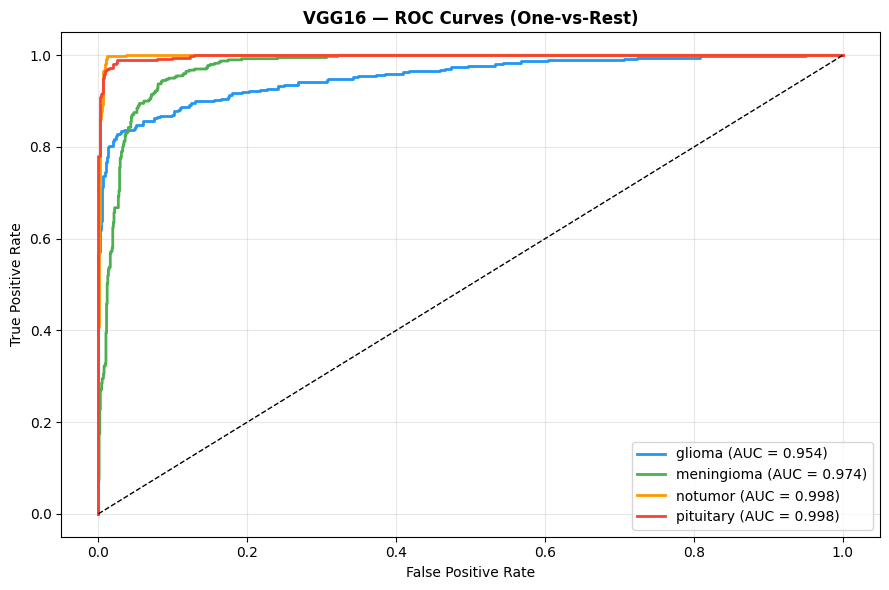

In [ ]:
# ROC-AUC curves
y_true_bin_vgg = label_binarize(y_true_vgg, classes=list(range(NUM_CLASSES)))
colours = ["#2196F3","#4CAF50","#FF9800","#F44336"]
plt.figure(figsize=(9, 6))
auc_scores_vgg = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colours)):
    fpr, tpr, _ = roc_curve(y_true_bin_vgg[:, i], y_pred_proba_vgg[:, i])
    score = auc(fpr, tpr)
    auc_scores_vgg.append(score)
    plt.plot(fpr, tpr, color=col, lw=2, label=f"{cls} (AUC = {score:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG16 — ROC Curves (One-vs-Rest)", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test accuracy and loss

In [ ]:
test_data_tl.reset()
vgg_loss, vgg_acc = vgg_model.evaluate(test_data_tl, verbose=0)
vgg_auc = np.mean(auc_scores_vgg)
total_time = round(p1_time + p2_time, 2)

print(f"\n{'='*45}")
print(f"  VGG16 — Final Results")
print(f"{'='*45}")
print(f"  Test Accuracy : {vgg_acc:.4f}")
print(f"  Test Loss     : {vgg_loss:.4f}")
print(f"  Macro AUC     : {vgg_auc:.4f}")
print(f"  Training Time : {total_time} minutes")
print(f"{'='*45}")


  VGG16 — Final Results
  Test Accuracy : 0.9119
  Test Loss     : 0.4171
  Macro AUC     : 0.9812
  Training Time : 13.99 minutes


# SECTION 18: SAVE VGG16 MODEL

In [ ]:
vgg_model.save("vgg16_final.keras")
print("VGG16 model saved as vgg16_final.keras")

VGG16 model saved as vgg16_final.keras


# **#ResNet50**

ResNet50 uses skip (residual) connections that allow gradients to flow through shortcut paths, solving the vanishing gradient problem in deep nets.
This makes it more effective than VGG16 at learning complex features.

RESNET50 — LOAD PRETRAINED BASE


In [ ]:
from tensorflow.keras.applications import ResNet50
import time

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# Freeze entire base for Phase 1
resnet_base.trainable = False

print(f"ResNet50 base layers   : {len(resnet_base.layers)}")
print(f"Trainable layers (P1)  : {sum(1 for l in resnet_base.layers if l.trainable)}")

# Attach classification head
resnet_model = build_transfer_model(resnet_base, NUM_CLASSES, "ResNet50")
resnet_model.summary()

ResNet50 base layers   : 175
Trainable layers (P1)  : 0


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# SECTION 19: PHASE 1 — FEATURE EXTRACTION (FROZEN BASE)

 Only the classification head is trained.
ResNet50 base weights are frozen to preserve ImageNet feature representations.

In [ ]:
EPOCHS_P1 = 10
LR_P1     = 0.001

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P1),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n" + "="*60)
print("  ResNet50 — Phase 1: Feature Extraction (Base Frozen)")
print("="*60)

start = time.time()

history_resnet_p1 = resnet_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=EPOCHS_P1,
    callbacks=get_callbacks("resnet50_phase1"),
    class_weight=class_weights,
    verbose=1
)
p1_time_resnet = round((time.time() - start) / 60, 2)
print(f"Phase 1 completed in {p1_time_resnet} minutes")


  ResNet50 — Phase 1: Feature Extraction (Base Frozen)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.6112 - loss: 0.9429
Epoch 1: val_loss improved from None to 0.80813, saving model to resnet50_phase1_best.keras

Epoch 1: finished saving model to resnet50_phase1_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 279ms/step - accuracy: 0.6136 - loss: 0.9402 - val_accuracy: 0.6848 - val_loss: 0.8081 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.6237 - loss: 0.9186
Epoch 2: val_loss did not improve from 0.80813
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 239ms/step - accuracy: 0.6259 - loss: 0.9099 - val_accuracy: 0.6661 - val_loss: 0.8312 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.6156 - loss: 0.9177
Epoch 3: val_loss did not improve from 0.80813
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 226ms/step - accuracy: 0.6250 - loss: 0.9022 - val_accuracy: 0.6759 - val_loss: 0.8305 - learning_rate: 0.0010


Phase 1 completed in 5.87 minutes


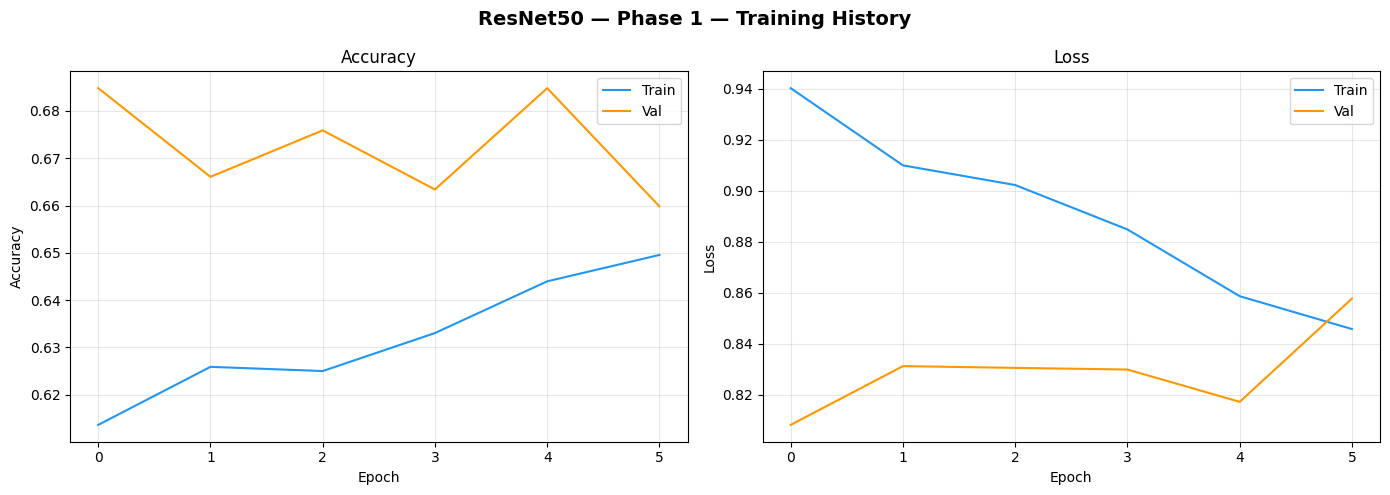

In [ ]:
plot_history(history_resnet_p1, "ResNet50 — Phase 1")

# SECTION 20: PHASE 2 — FINE-TUNING (UNFREEZE LAST 10 LAYERS)

The last 10 layers correspond to the final residual block of ResNet50.
- Unfreezing this block allows the model to adapt high-level feature representations to MRI image characteristics.
- Lower LR = 0.0001 prevents overwriting pretrained weights too aggressively.


Trainable layers after unfreeze: 14

  ResNet50 — Phase 2: Fine-Tuning (Last 10 Layers Unfrozen)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5485 - loss: 3.9135
Epoch 1: val_loss improved from None to 1.77352, saving model to resnet50_phase2_best.keras

Epoch 1: finished saving model to resnet50_phase2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - accuracy: 0.6275 - loss: 1.5806 - val_accuracy: 0.4241 - val_loss: 1.7735 - learning_rate: 1.0000e-04
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6930 - loss: 0.7479
Epoch 2: val_loss did not improve from 1.77352
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 227ms/step - accuracy: 0.7033 - loss: 0.7322 - val_accuracy: 0.3562 - val_loss: 1.7951 - learning_rate: 1.0000e-04
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7176 - loss: 0.6940
Epoch 3: val_loss improved from 1.77352 to 1.20817, saving model to resnet50_phase2_best.keras

Epoch 3: finished saving model to resnet50_ph

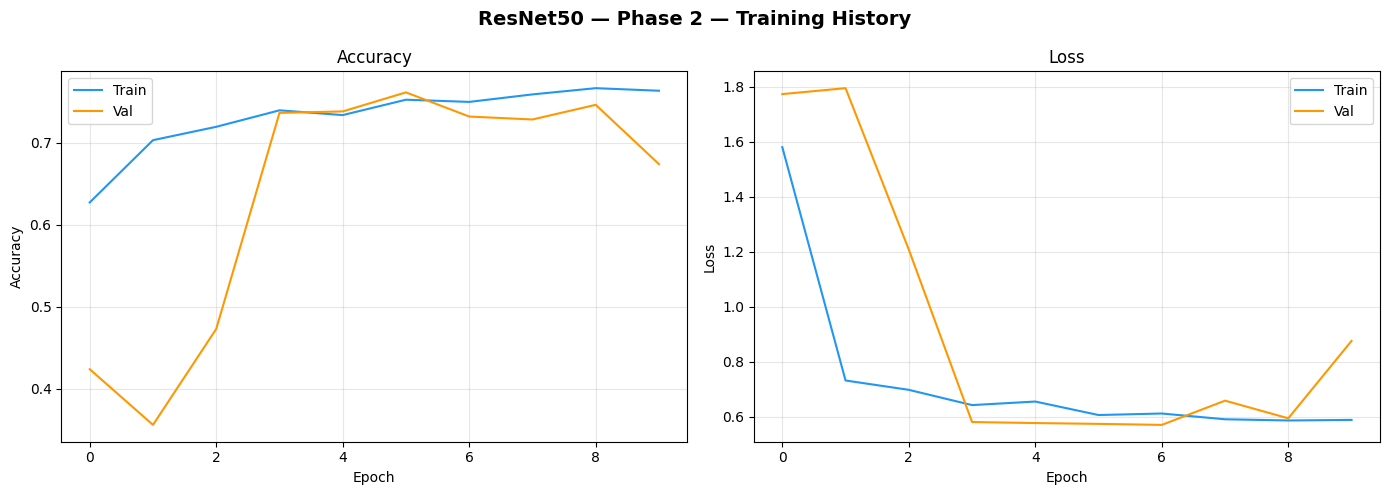

In [ ]:
resnet_base.trainable = True

# Freeze all layers except the last 10
for layer in resnet_base.layers[:-10]:
    layer.trainable = False

trainable = sum(1 for l in resnet_model.layers if l.trainable)
print(f"\nTrainable layers after unfreeze: {trainable}")

EPOCHS_P2 = 10
LR_P2     = 0.0001

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n" + "="*60)
print("  ResNet50 — Phase 2: Fine-Tuning (Last 10 Layers Unfrozen)")
print("="*60)

start = time.time()

history_resnet_p2 = resnet_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=EPOCHS_P2,
    callbacks=get_callbacks("resnet50_phase2"),
    class_weight=class_weights,
    verbose=1
)

p2_time_resnet = round((time.time() - start) / 60, 2)
print(f"Phase 2 completed in {p2_time_resnet} minutes")


In [ ]:
plot_history(history_resnet_p2, "ResNet50 — Phase 2")

# SECTION 21: RESNET50 EVALUATION

In [ ]:
test_data_tl.reset()
y_pred_proba_resnet = resnet_model.predict(test_data_tl, verbose=1)
y_pred_resnet       = np.argmax(y_pred_proba_resnet, axis=1)
y_true_resnet       = test_data_tl.classes

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step


## Classification report

In [ ]:
print("\nResNet50 — Classification Report:")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=CLASS_NAMES))


ResNet50 — Classification Report:
              precision    recall  f1-score   support

      glioma       0.85      0.32      0.46       400
  meningioma       0.57      0.58      0.57       400
     notumor       0.70      0.96      0.81       400
   pituitary       0.75      0.93      0.83       400

    accuracy                           0.70      1600
   macro avg       0.72      0.70      0.67      1600
weighted avg       0.72      0.70      0.67      1600



## Confusion matrix

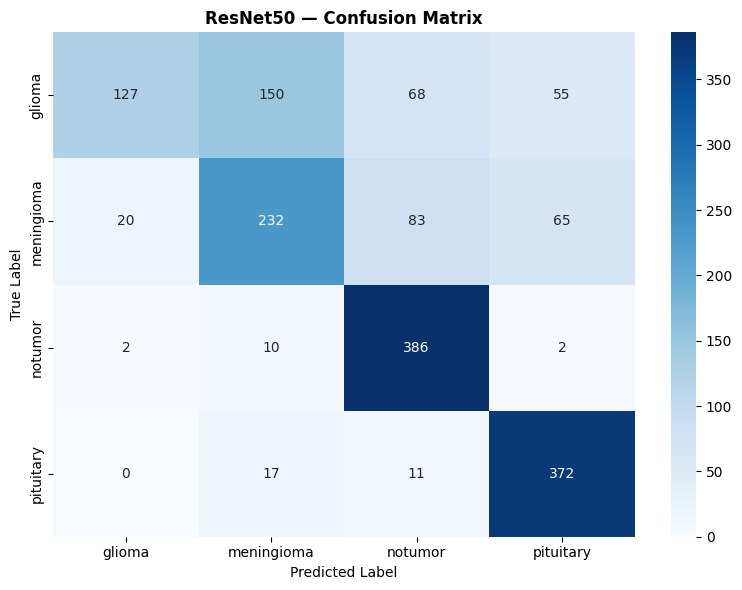

In [ ]:
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("ResNet50 — Confusion Matrix", fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## ROC-AUC curves

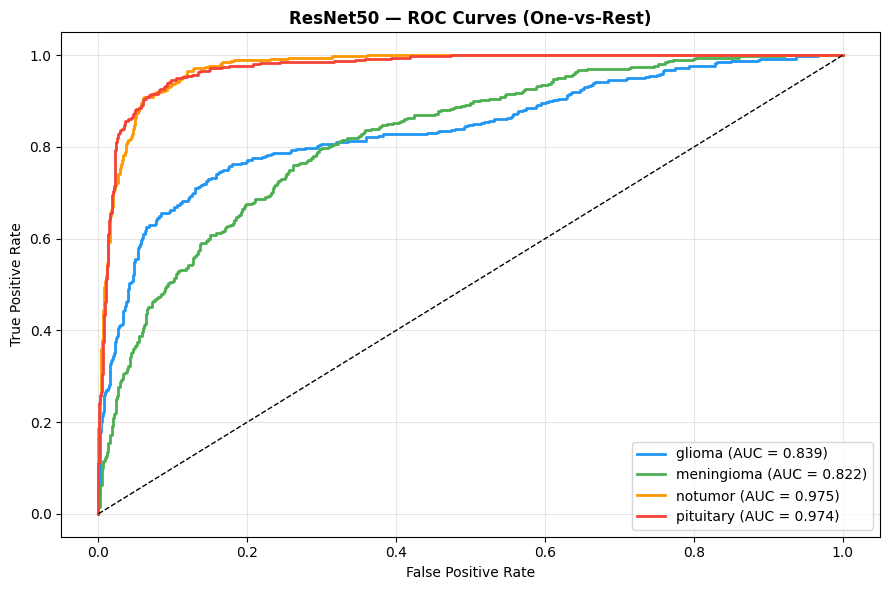

In [ ]:
y_true_bin_resnet = label_binarize(y_true_resnet, classes=list(range(NUM_CLASSES)))
colours = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
plt.figure(figsize=(9, 6))
auc_scores_resnet = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colours)):
    fpr, tpr, _ = roc_curve(y_true_bin_resnet[:, i], y_pred_proba_resnet[:, i])
    score = auc(fpr, tpr)
    auc_scores_resnet.append(score)
    plt.plot(fpr, tpr, color=col, lw=2, label=f"{cls} (AUC = {score:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 — ROC Curves (One-vs-Rest)", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Test accuracy and loss

In [ ]:
test_data_tl.reset()
resnet_loss, resnet_acc = resnet_model.evaluate(test_data_tl, verbose=0)
resnet_auc  = np.mean(auc_scores_resnet)
total_time_resnet = round(p1_time_resnet + p2_time_resnet, 2)

print(f"\n{'='*45}")
print(f"  ResNet50 — Final Results")
print(f"{'='*45}")
print(f"  Test Accuracy : {resnet_acc:.4f}")
print(f"  Test Loss     : {resnet_loss:.4f}")
print(f"  Macro AUC     : {resnet_auc:.4f}")
print(f"  Training Time : {total_time_resnet} minutes")
print(f"{'='*45}")


  ResNet50 — Final Results
  Test Accuracy : 0.6981
  Test Loss     : 0.9127
  Macro AUC     : 0.9025
  Training Time : 11.87 minutes



# SECTION 22: SAVE RESNET50 MODEL

In [ ]:
resnet_model.save("resnet50_final.keras")
print("ResNet50 model saved as resnet50_final.keras")

ResNet50 model saved as resnet50_final.keras


# **#EFFICIENTNETB0**

Two-Phase Training Strategy:
- Phase 1
 Feature Extraction : EfficientNetB0 base frozen, only head trained (LR=0.001)

- Phase 2
Fine-Tuning        : Last 20 layers unfrozen (LR=0.0001)

- EfficientNetB0 uses compound scaling to balance depth, width and resolution, achieving strong accuracy with significantly fewer parameters than VGG16 or ResNet50. This makes it computationally efficient while remaining
highly competitive in classification performance.

# SECTION 23: EFFICIENTNETB0 — LOAD PRETRAINED BASE

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
import time

effnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

In [ ]:
# Freeze entire base for Phase 1
effnet_base.trainable = False

print(f"EfficientNetB0 base layers : {len(effnet_base.layers)}")
print(f"Trainable layers (P1)      : {sum(1 for l in effnet_base.layers if l.trainable)}")
 # Attaching classification head — same shared head used across all TL models:
# GlobalAveragePooling → Dense(256, ReLU) → Dropout(0.5) → Softmax(4)
effnet_model = build_transfer_model(effnet_base, NUM_CLASSES, "EfficientNetB0")
effnet_model.summary()


EfficientNetB0 base layers : 238
Trainable layers (P1)      : 0


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 128, 128,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 128, 128,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 128, 128,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# SECTION 24: PHASE 1 — FEATURE EXTRACTION (FROZEN BASE)

Only the classification head is trained.
EfficientNetB0 base weights are frozen to preserve ImageNet features.

In [ ]:
EPOCHS_P1 = 10
LR_P1     = 0.001

effnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P1),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n" + "="*60)
print("  EfficientNetB0 — Phase 1: Feature Extraction (Base Frozen)")
print("="*60)

start = time.time()

history_effnet_p1 = effnet_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=EPOCHS_P1,
    callbacks=get_callbacks("effnet_phase1"),
    class_weight=class_weights,
    verbose=1
)
p1_time_effnet = round((time.time() - start) / 60, 2)
print(f"Phase 1 completed in {p1_time_effnet} minutes")


  EfficientNetB0 — Phase 1: Feature Extraction (Base Frozen)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.2501 - loss: 1.4596
Epoch 1: val_loss improved from None to 1.38657, saving model to effnet_phase1_best.keras

Epoch 1: finished saving model to effnet_phase1_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 143s 407ms/step - accuracy: 0.2478 - loss: 1.4208 - val_accuracy: 0.2500 - val_loss: 1.3866 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.2514 - loss: 1.3868
Epoch 2: val_loss improved from 1.38657 to 1.38630, saving model to effnet_phase1_best.keras

Epoch 2: finished saving model to effnet_phase1_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 311ms/step - accuracy: 0.2458 - loss: 1.3867 - val_accuracy: 0.2500 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2423 - loss: 1.3864
Epoch 3: val_loss improved from 1.38630 to 1.38630, saving model to effnet_phase1_

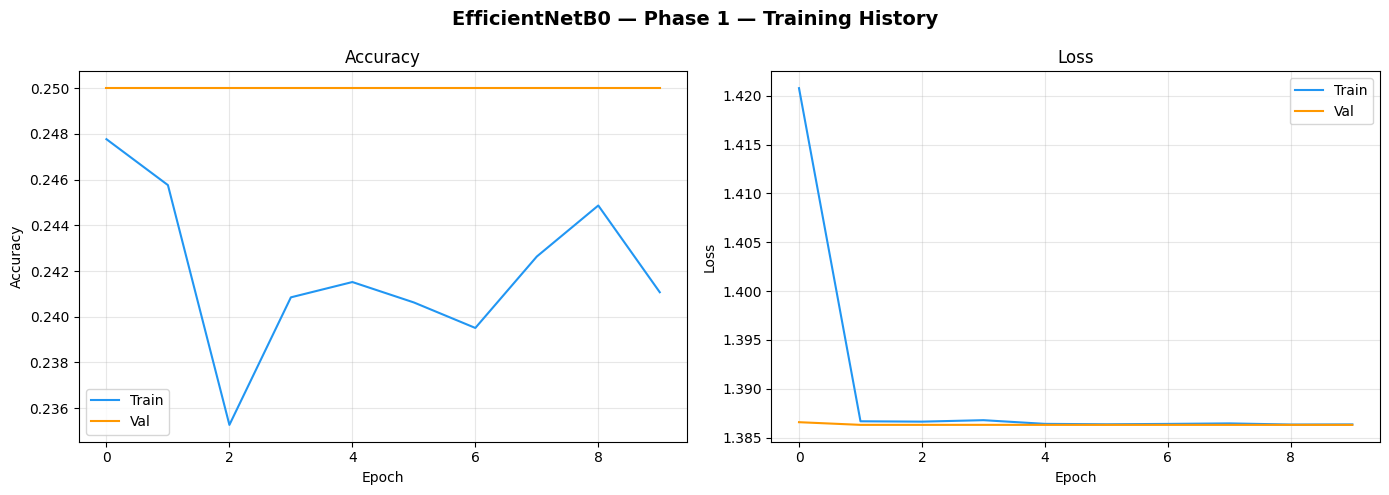

In [ ]:
plot_history(history_effnet_p1, "EfficientNetB0 — Phase 1")

# SECTION 25: PHASE 2 — FINE-TUNING (UNFREEZE LAST 20 LAYERS)

EfficientNetB0 has more layers than VGG16, so we unfreezed the last 20 to expose a meaningful portion of the upper network for domain adaptation.
- Lower LR = 0.0001 prevents overwriting pretrained weights too aggressively.

In [ ]:
effnet_base.trainable = True

In [ ]:
# Freeze all layers except the last 20
for layer in effnet_base.layers[:-20]:
    layer.trainable = False

trainable = sum(1 for l in effnet_model.layers if l.trainable)
print(f"\nTrainable layers after unfreeze: {trainable}")

EPOCHS_P2 = 10
LR_P2     = 0.0001

effnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P2),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n" + "="*60)
print("  EfficientNetB0 — Phase 2: Fine-Tuning (Last 20 Layers Unfrozen)")
print("="*60)

start = time.time()

history_effnet_p2 = effnet_model.fit(
    train_data_tl,
    validation_data=val_data_tl,
    epochs=EPOCHS_P2,
    callbacks=get_callbacks("effnet_phase2"),
    class_weight=class_weights,
    verbose=1
)
p2_time_effnet = round((time.time() - start) / 60, 2)
print(f"Phase 2 completed in {p2_time_effnet} minutes")


Trainable layers after unfreeze: 24

  EfficientNetB0 — Phase 2: Fine-Tuning (Last 20 Layers Unfrozen)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.2603 - loss: 1.4425
Epoch 1: val_loss improved from None to 1.38665, saving model to effnet_phase2_best.keras

Epoch 1: finished saving model to effnet_phase2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 150s 593ms/step - accuracy: 0.2763 - loss: 1.4036 - val_accuracy: 0.2143 - val_loss: 1.3867 - learning_rate: 1.0000e-04
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3013 - loss: 1.3749
Epoch 2: val_loss improved from 1.38665 to 1.38073, saving model to effnet_phase2_best.keras

Epoch 2: finished saving model to effnet_phase2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 314ms/step - accuracy: 0.3107 - loss: 1.3650 - val_accuracy: 0.2500 - val_loss: 1.3807 - learning_rate: 1.0000e-04
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.3479 - loss: 1.3280
Epoch 3: val_loss improved from 

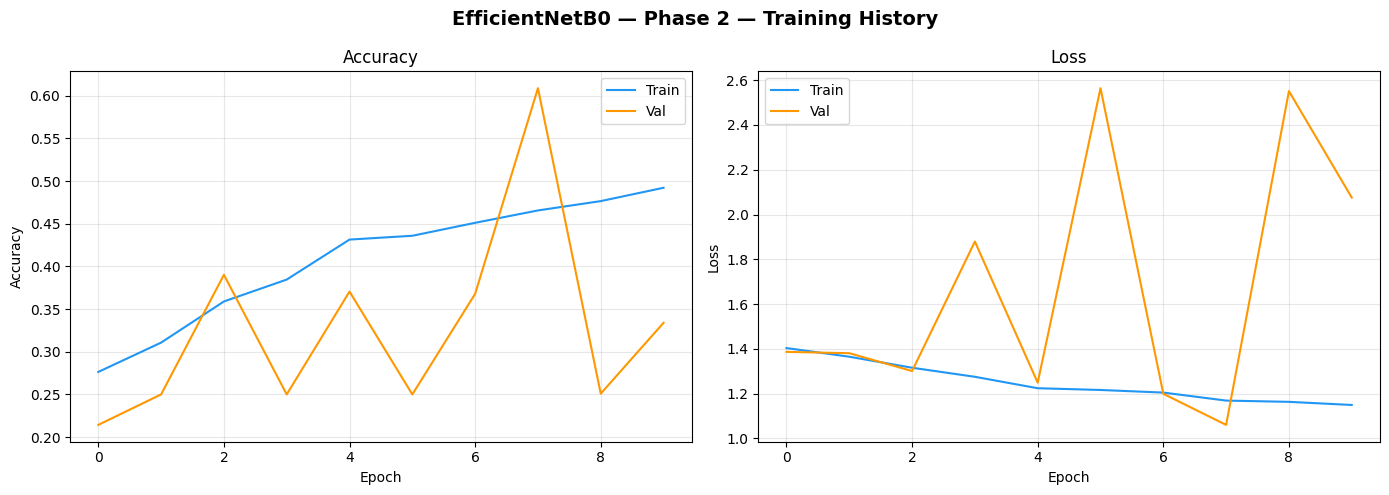

In [ ]:
plot_history(history_effnet_p2, "EfficientNetB0 — Phase 2")

# SECTION 26: EFFICIENTNETB0 EVALUATION

In [ ]:
test_data_tl.reset()
y_pred_proba_effnet = effnet_model.predict(test_data_tl, verbose=1)
y_pred_effnet       = np.argmax(y_pred_proba_effnet, axis=1)
y_true_effnet       = test_data_tl.classes

50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step


## Classification report

In [ ]:
print("\nEfficientNetB0 — Classification Report:")
print(classification_report(y_true_effnet, y_pred_effnet, target_names=CLASS_NAMES))


EfficientNetB0 — Classification Report:
              precision    recall  f1-score   support

      glioma       0.53      0.54      0.54       400
  meningioma       0.51      0.29      0.37       400
     notumor       0.57      0.74      0.64       400
   pituitary       0.61      0.69      0.65       400

    accuracy                           0.57      1600
   macro avg       0.56      0.57      0.55      1600
weighted avg       0.56      0.57      0.55      1600



## Confusion matrix

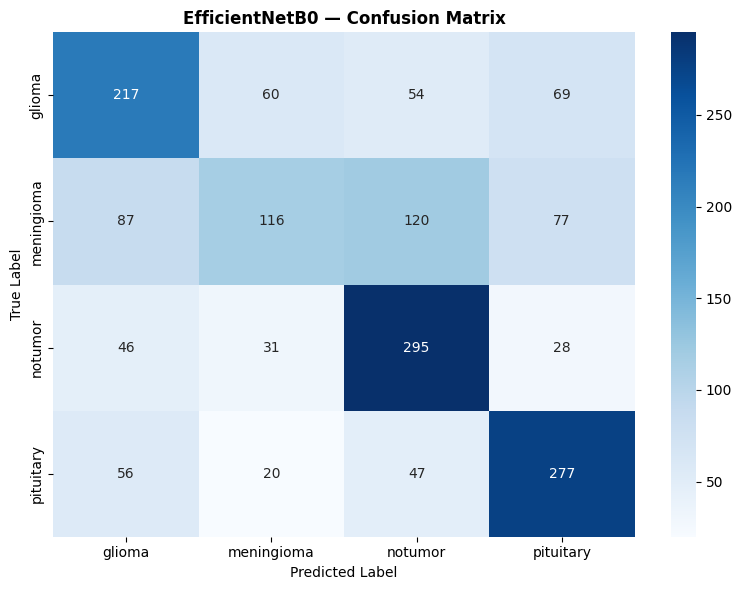

In [ ]:
cm_effnet = confusion_matrix(y_true_effnet, y_pred_effnet)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_effnet, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("EfficientNetB0 — Confusion Matrix", fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## ROC-AUC curves

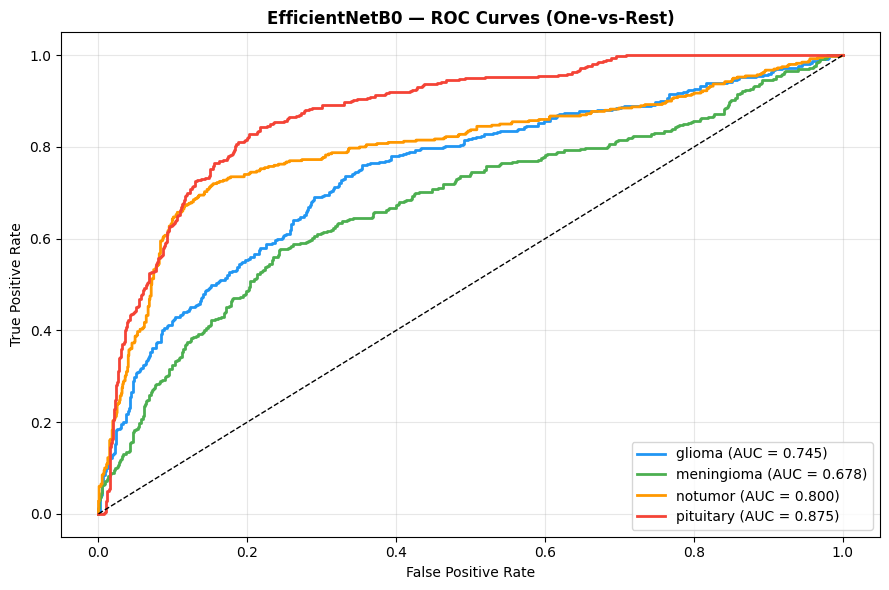

In [ ]:
y_true_bin_effnet = label_binarize(y_true_effnet, classes=list(range(NUM_CLASSES)))
colours = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
plt.figure(figsize=(9, 6))
auc_scores_effnet = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colours)):
    fpr, tpr, _ = roc_curve(y_true_bin_effnet[:, i], y_pred_proba_effnet[:, i])
    score = auc(fpr, tpr)
    auc_scores_effnet.append(score)
    plt.plot(fpr, tpr, color=col, lw=2, label=f"{cls} (AUC = {score:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("EfficientNetB0 — ROC Curves (One-vs-Rest)", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Test accuracy and loss

In [ ]:
test_data_tl.reset()
effnet_loss, effnet_acc = effnet_model.evaluate(test_data_tl, verbose=0)
effnet_auc = np.mean(auc_scores_effnet)
total_time_effnet = round(p1_time_effnet + p2_time_effnet, 2)

print(f"\n{'='*45}")
print(f"  EfficientNetB0 — Final Results")
print(f"{'='*45}")
print(f"  Test Accuracy : {effnet_acc:.4f}")
print(f"  Test Loss     : {effnet_loss:.4f}")
print(f"  Macro AUC     : {effnet_auc:.4f}")
print(f"  Training Time : {total_time_effnet} minutes")
print(f"{'='*45}")


  EfficientNetB0 — Final Results
  Test Accuracy : 0.5656
  Test Loss     : 1.3574
  Macro AUC     : 0.7742
  Training Time : 15.98 minutes


# SECTION 27: SAVE EFFICIENTNETB0 MODEL

In [ ]:
effnet_model.save("efficientnetb0_final.keras")
print("EfficientNetB0 model saved as efficientnetb0_final.keras")

EfficientNetB0 model saved as efficientnetb0_final.keras


# SECTION 28: FINAL COMPARATIVE RESULTS TABLE

In [ ]:
import pandas as pd

results = pd.DataFrame([
    {
        "Model"         : "Custom CNN",
        "Test Accuracy" : test_acc,        # from custom_cnn_clean.py Section 11
        "Test Loss"     : test_loss,
        "Macro AUC"     : macro_auc,
    },
    {
        "Model"         : "VGG16",
        "Test Accuracy" : vgg_acc,
        "Test Loss"     : vgg_loss,
        "Macro AUC"     : vgg_auc,
    },
    {
        "Model"         : "ResNet50",
        "Test Accuracy" : resnet_acc,
        "Test Loss"     : resnet_loss,
        "Macro AUC"     : resnet_auc,
    },
    {
        "Model"         : "EfficientNetB0",
        "Test Accuracy" : effnet_acc,
        "Test Loss"     : effnet_loss,
        "Macro AUC"     : effnet_auc,
    },
])

print("\n" + "="*65)
print("  FINAL COMPARATIVE MODEL PERFORMANCE SUMMARY")
print("="*65)
print(results.to_string(index=False))


  FINAL COMPARATIVE MODEL PERFORMANCE SUMMARY
         Model  Test Accuracy  Test Loss  Macro AUC
    Custom CNN       0.780625   0.800537   0.925358
         VGG16       0.911875   0.417088   0.981249
      ResNet50       0.698125   0.912688   0.902477
EfficientNetB0       0.565625   1.357431   0.774248


# COMPARATIVE CHARTS

This section generates 3 separate charts: Test Accuracy, Test Loss and Macro AUC for all our 4 models
Our colour palette is healthcare/medical themed, that is muted blues, teals, greys

In [ ]:
COLOURS = [
    "#4A7C9E",   # Steel blue     — Custom CNN
    "#5B8C6E",   # Muted teal     — VGG16
    "#7D6B8E",   # Dusty purple   — ResNet50
    "#8E7260",   # Warm slate     — EfficientNetB0
]

models     = results["Model"].tolist()
x          = np.arange(len(models))
bar_width  = 0.5

FONT_TITLE  = {"fontsize": 13, "fontweight": "bold", "color": "#2C2C2C"}
FONT_AXIS   = {"fontsize": 11, "color": "#2C2C2C"}
FONT_TICK   = {"fontsize": 10}
GRID_STYLE  = {"axis": "y", "linestyle": "--", "alpha": 0.4, "color": "#AAAAAA"}

def style_ax(ax):
    """Apply consistent clean styling to each chart axis."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.tick_params(colors="#2C2C2C")
    ax.grid(**GRID_STYLE)
    ax.set_facecolor("#FAFAFA")

## CHART 1 — TEST ACCURACY

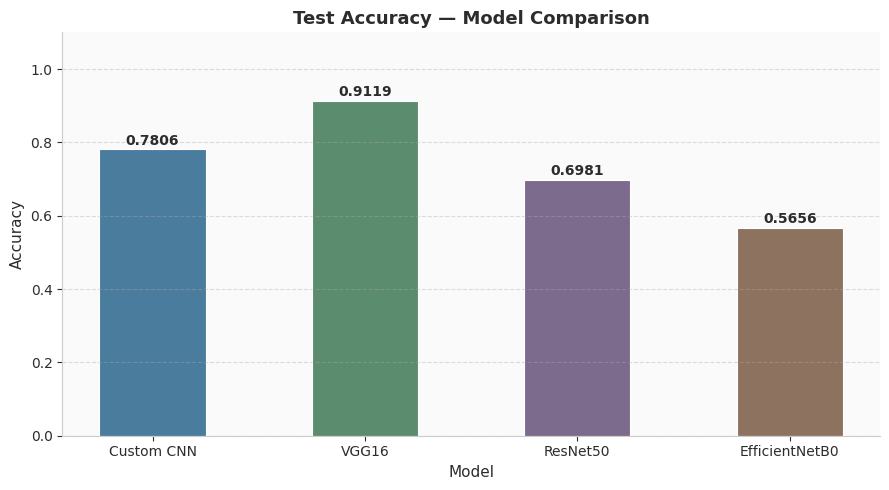

Saved: chart_test_accuracy.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#FFFFFF")

bars = ax.bar(x, results["Test Accuracy"], width=bar_width,
              color=COLOURS, edgecolor="white", linewidth=0.8)

# Value labels on top of each bar
for bar, val in zip(bars, results["Test Accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#2C2C2C"
    )

ax.set_title("Test Accuracy — Model Comparison", **FONT_TITLE)
ax.set_ylabel("Accuracy", **FONT_AXIS)
ax.set_xlabel("Model", **FONT_AXIS)
ax.set_xticks(x)
ax.set_xticklabels(models, **FONT_TICK)
ax.set_ylim(0, 1.1)
style_ax(ax)

plt.tight_layout()
plt.savefig("chart_test_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_test_accuracy.png")

## CHART 2 — TEST LOSS

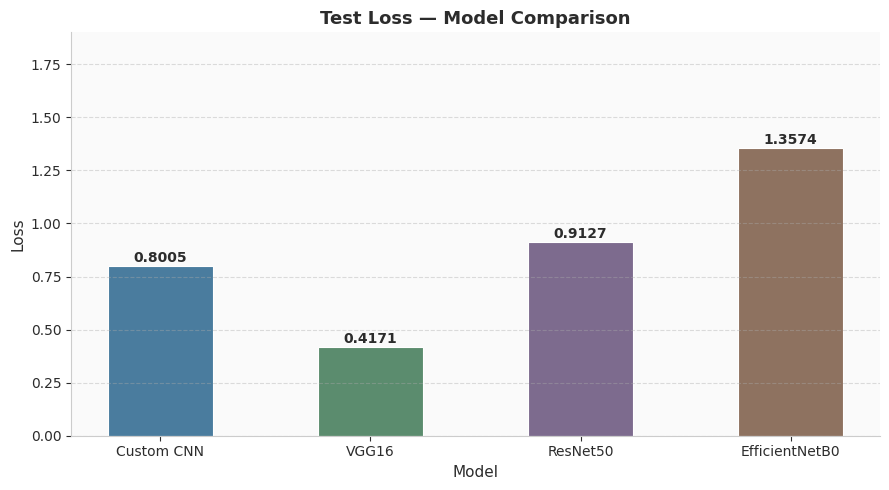

Saved: chart_test_loss.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#FFFFFF")

bars = ax.bar(x, results["Test Loss"], width=bar_width,
              color=COLOURS, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, results["Test Loss"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#2C2C2C"
    )

ax.set_title("Test Loss — Model Comparison", **FONT_TITLE)
ax.set_ylabel("Loss", **FONT_AXIS)
ax.set_xlabel("Model", **FONT_AXIS)
ax.set_xticks(x)
ax.set_xticklabels(models, **FONT_TICK)
# Lower loss is better — set ylim generously to show differences clearly
ax.set_ylim(0, max(results["Test Loss"]) * 1.4)
style_ax(ax)

plt.tight_layout()
plt.savefig("chart_test_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_test_loss.png")

## CHART 3 — MACRO AUC

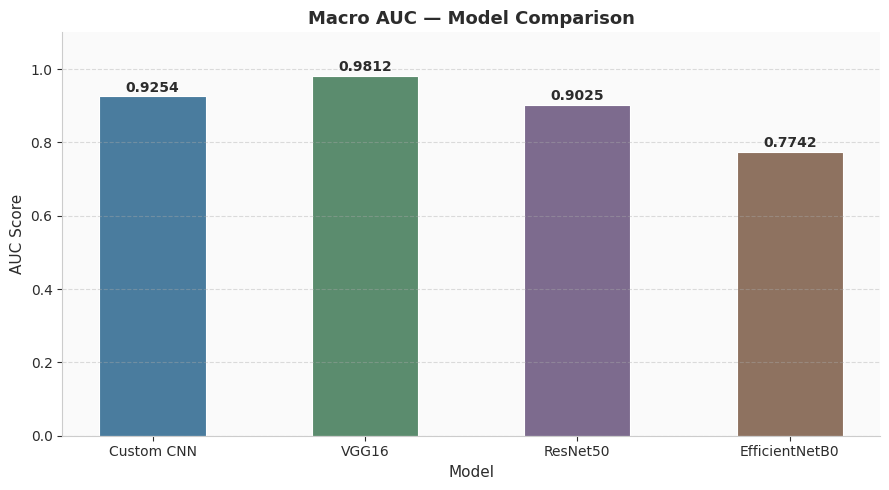

Saved: chart_macro_auc.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#FFFFFF")

bars = ax.bar(x, results["Macro AUC"], width=bar_width,
              color=COLOURS, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, results["Macro AUC"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#2C2C2C"
    )

ax.set_title("Macro AUC — Model Comparison", **FONT_TITLE)
ax.set_ylabel("AUC Score", **FONT_AXIS)
ax.set_xlabel("Model", **FONT_AXIS)
ax.set_xticks(x)
ax.set_xticklabels(models, **FONT_TICK)
ax.set_ylim(0, 1.1)
style_ax(ax)

plt.tight_layout()
plt.savefig("chart_macro_auc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_macro_auc.png")

In [ ]:
print("\nColour reference:")
palette = {
    "Custom CNN"     : "#4A7C9E  (Steel Blue)",
    "VGG16"          : "#5B8C6E  (Muted Teal)",
    "ResNet50"       : "#7D6B8E  (Dusty Purple)",
    "EfficientNetB0" : "#8E7260  (Warm Slate)",
}
for model, colour in palette.items():
    print(f"  {model:<18} → {colour}")


Colour reference:
  Custom CNN         → #4A7C9E  (Steel Blue)
  VGG16              → #5B8C6E  (Muted Teal)
  ResNet50           → #7D6B8E  (Dusty Purple)
  EfficientNetB0     → #8E7260  (Warm Slate)
